# Домашнее задание - линейная регрессия

### Работа с признаками (8 баллов)

Скачайте датасет из материалов к уроку или по ссылке https://raw.githubusercontent.com/jupiterzhuo/travel-insurance/master/travel%20insurance.csv 


Описание признаков:

* Agency — название страхового агентства
* Agency Type — тип страхового агентства
* Distribution Channel — канал продвижения страхового агентства
* Product Name — название страхового продукта
* Duration — длительность поездки (количество дней)
* Destination — направление поездки
* Net Sales — сумма продаж 
* Commission (in value) — комиссия страхового агентства
* Gender — пол застрахованного
* Age — возраст застрахованного

Ответ:
* Claim — потребовалась ли страховая выплата: «да» — 1, «нет» — 0

Обработайте пропущенные значения и примените написанные функции onehot_encode() и minmax_scale().

**Подсказка**: маску для категориальных признаков можно сделать фильтром cat_features_mask = (df.dtypes == "object").values

In [1]:
# импортирум все необходимое
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
#"примените написанные функции" не совсем понял, но на всякий случай буду использовать функции из прошлых заданий
def onehot_encoding(x: np.ndarray):
    L = len(x)
    x1 = np.sort(x)
    w = {}
    N = 0
    for j in x1:
        if j not in w:
            w[j] = N
            N += 1

    f = np.eye(N, N, dtype = np.float32)
    Q = np.empty([L, N], np.float32)
    for j, i in enumerate(x):
        Q[j] = f[w[i]]

    return Q


def minmax_scale(X: np.ndarray):
    if len(X) <= 1:
        return np.zeros_like(X, np.float32)
    Mi = X.min(axis=0)
    Ma = X.max(axis=0)
    return (X - Mi) / (Ma - Mi)


#### Обрабатываю NaN

In [3]:
df = pd.read_csv("travel insurance.csv")

In [4]:
# первым делом посмотрим сколько промущенных значений встречается в данных
Nans = df[df.isnull().any(axis=1)] # берем все строки в которых есть хотя бы 1 Nan
RowCount = df.shape[0]
NaNRowCount = Nans.shape[0]

NaNRowCount/RowCount

0.7122982661150239

In [5]:
# теперь посмотрим сколько Nan - ов в каждой коллонке
df.isnull().sum(axis=0)

Agency                      0
Agency Type                 0
Distribution Channel        0
Product Name                0
Claim                       0
Duration                    0
Destination                 0
Net Sales                   0
Commision (in value)        0
Gender                  45107
Age                         0
dtype: int64

In [6]:
# Как можно заметить все Наны содержатся в колонке Gender
# 71% данных в этой колонке неизвестны, будет разумно избавиться от неё

df = df.drop(columns='Gender', axis=1)
df

,Agency,Agency Type,Distribution Channel,Product Name,Claim,Duration,Destination,Net Sales,Commision (in value),Age
0,CBH,Travel Agency,Offline,Comprehensive Plan,No,186,MALAYSIA,-29.0,9.57,81
1,CBH,Travel Agency,Offline,Comprehensive Plan,No,186,MALAYSIA,-29.0,9.57,71
2,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,No,65,AUSTRALIA,-49.5,29.70,32
3,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,No,60,AUSTRALIA,-39.6,23.76,32
4,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,No,79,ITALY,-19.8,11.88,41
...,...,...,...,...,...,...,...,...,...,...
63321,JZI,Airlines,Online,Basic Plan,No,111,JAPAN,35.0,12.25,31
63322,JZI,Airlines,Online,Basic Plan,No,58,CHINA,40.0,14.00,40
63323,JZI,Airlines,Online,Basic Plan,No,2,MALAYSIA,18.0,6.30,57
63324,JZI,Airlines,Online,Basic Plan,No,3,VIET NAM,18.0,6.30,63


#### Подробный анализ и подготовка датасета

Подробный анализ и подготовка датасета часто помогают улучшить качество модели. Ниже представлено несколько идей преобразований. Вы можете применить одно или несколько из этих преобразований (а можете не применять), чтобы помочь будущей модели. 

1. Посмотрите на количественные признаки. Возможно, в некоторых признаках есть выбросы - значения, которые сильно выбиваются. Такие значения полезно удалять. Советуем присмотреться к колонке Duration)

2. Можно заметить, что one hot encoding сильно раздувает количество столбцов. Радикальное решение - можно попробовать выбросить все категориальные признаки из датасета.

3. Если все-таки оставляете категориальные признаки, то подумайте, как уменьшить количество столбцов после one hot encoding. Признаки с большим количеством значений (Duration - 149! разных стран) можно удалить или попробовать сгруппировать некоторые значения.

4. Downsampling. Датасет достаточно большой, разница в классах огромная. Можно уменьшить число наблюдений с частым ответом.

##### Применяю Функции 

Перед подготовкой данных нужно понять, а сколько различных значений у каждого признака есть

###### Фильтруем признаки

In [7]:
df.select_dtypes("object").nunique()

Agency                   16
Agency Type               2
Distribution Channel      2
Product Name             26
Claim                     2
Destination             149
dtype: int64

In [8]:
# Очень маловероятно, что Distribution Channel способен повлиять на страховую выплату
df = df.drop(columns='Distribution Channel', axis=1)

Будет размуно посмотреть как связаны категориальные признаки и Claim

In [9]:
def get_claim_info(value_name, print_info = True, pie_bias = 0): # показывает количество страховых выплат по категориальному параметру
    global df
    VU = df[value_name].unique()
    HH = {}
    for v in VU:
        s = sum(df[df[value_name] == v]['Claim'] == 'Yes')
        if print_info:print(f"{v} : {s}")
        HH[v] = s

    return HH

def show_all(print_info = True, pie_bias = 0): # pie_bias нужен для того, что бы на диаграмме так же можно было увидеть значения 0
    q = list(df.dtypes[df.dtypes == "object"].keys())
    q.remove('Claim')
    for g in q:
        print(f"============ {g} ==================")
        HH = get_claim_info(g, pie_bias=-pie_bias)
        plt.pie(np.array(list(HH.values())) + pie_bias, labels = HH.keys())
        plt.show()

============ Agency ==================
CBH : 1
CWT : 86
JZI : 31
KML : 8
EPX : 195
C2B : 547
JWT : 4
RAB : 1
SSI : 7
ART : 1
CSR : 1
CCR : 3
ADM : 0
LWC : 36
TTW : 4
TST : 2


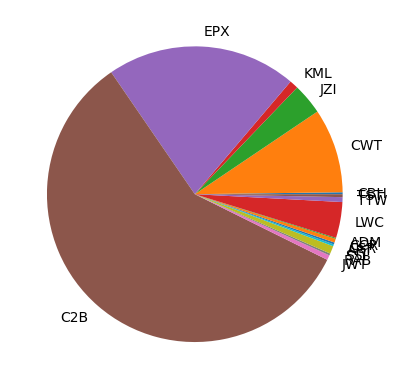

============ Agency Type ==================
Travel Agency : 336
Airlines : 591


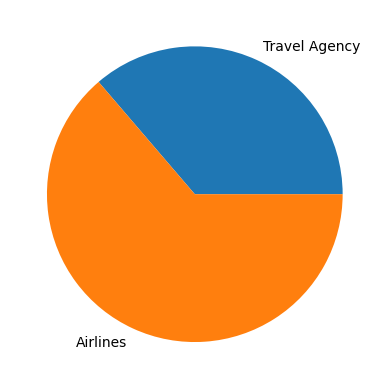

============ Product Name ==================
Comprehensive Plan : 5
Rental Vehicle Excess Insurance : 86
Value Plan : 19
Basic Plan : 23
Premier Plan : 3
2 way Comprehensive Plan : 142
Bronze Plan : 210
Silver Plan : 141
Annual Silver Plan : 157
Cancellation Plan : 44
1 way Comprehensive Plan : 9
Ticket Protector : 7
24 Protect : 0
Gold Plan : 18
Annual Gold Plan : 21
Single Trip Travel Protect Silver : 4
Individual Comprehensive Plan : 3
Spouse or Parents Comprehensive Plan : 1
Annual Travel Protect Silver : 4
Single Trip Travel Protect Platinum : 5
Annual Travel Protect Gold : 10
Single Trip Travel Protect Gold : 10
Annual Travel Protect Platinum : 3
Child Comprehensive Plan : 0
Travel Cruise Protect : 2
Travel Cruise Protect Family : 0


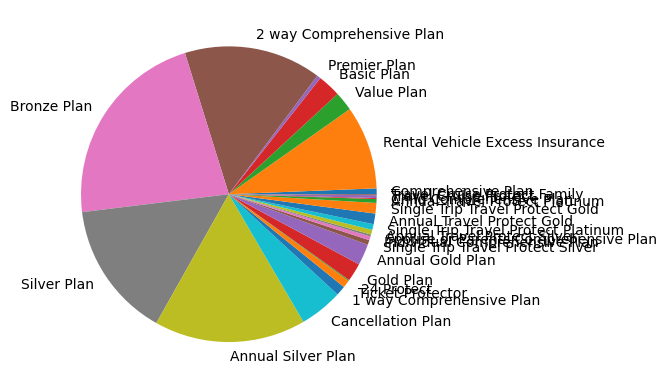

============ Destination ==================
MALAYSIA : 23
AUSTRALIA : 38
ITALY : 9
UNITED STATES : 37
THAILAND : 34
KOREA, DEMOCRATIC PEOPLE'S REPUBLIC OF : 0
NORWAY : 1
VIET NAM : 12
DENMARK : 0
SINGAPORE : 562
JAPAN : 14
UNITED KINGDOM : 16
INDONESIA : 15
INDIA : 8
CHINA : 46
FRANCE : 8
TAIWAN, PROVINCE OF CHINA : 6
PHILIPPINES : 8
MYANMAR : 1
HONG KONG : 15
KOREA, REPUBLIC OF : 15
UNITED ARAB EMIRATES : 2
NAMIBIA : 0
NEW ZEALAND : 4
COSTA RICA : 1
BRUNEI DARUSSALAM : 2
POLAND : 0
SPAIN : 5
CZECH REPUBLIC : 2
GERMANY : 5
SRI LANKA : 0
CAMBODIA : 1
AUSTRIA : 0
SOUTH AFRICA : 5
TANZANIA, UNITED REPUBLIC OF : 0
LAO PEOPLE'S DEMOCRATIC REPUBLIC : 1
NEPAL : 3
NETHERLANDS : 6
MACAO : 1
CROATIA : 0
FINLAND : 1
CANADA : 7
TUNISIA : 0
RUSSIAN FEDERATION : 0
GREECE : 1
BELGIUM : 0
IRELAND : 0
SWITZERLAND : 5
CHILE : 0
ISRAEL : 1
BANGLADESH : 0
ICELAND : 3
PORTUGAL : 0
ROMANIA : 0
KENYA : 0
GEORGIA : 0
TURKEY : 1
SWEDEN : 0
MALDIVES : 0
ESTONIA : 0
SAUDI ARABIA : 0
PAKISTAN : 0
QATAR : 0
PERU :

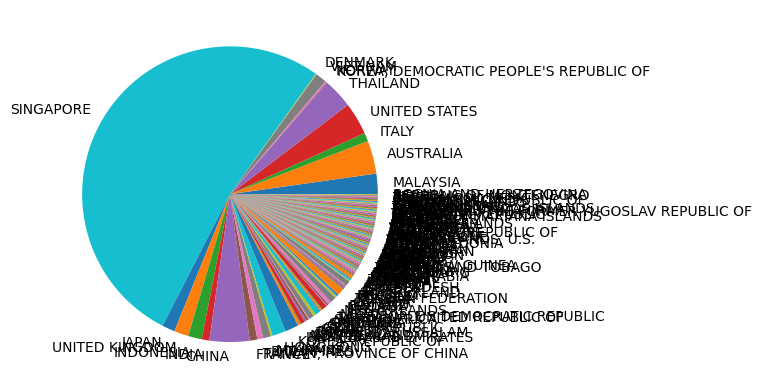

In [10]:
show_all(pie_bias = 1)

**Вывод**
1) Как можно заметить, страны можно отнести к 4 классам по вероятности выплаты страховки - маленькая , средняя, большая и сингапур
2) агенства тоже можно разделить на классы : маленькие, средние и С2B
3) Тип агенства и так маленький, его можно не менять
4) Product name - тоже можно разделить на классы


Как я собираюсь делить на классы?

1) Я выберу несколько точек за центры классов, т.е такие точки, которые по моему мнению являются "евклидовыми центрами" классов.
2) Затем для всех остальных точек, я найду ближайший "евклидовый центр", какой центр ближайший, к такому классу точка и относится

Такое разбиение пространства, если я правильно помню, называется "разбиением Вороного"

In [11]:
def voronoi(points: dict, classes_start_points: dict) -> dict: #| на вход принимает словарь по типу 
    out_v = {}                                                                #| название точки <-> координаты
    for v in points:                                                          #| и словарь по типу 
        # ищу ближайший к точке центр                                         #| старое название точки <-> новое название точки (или класс)
        kmin = min(list(classes_start_points.keys()), key=lambda x: np.dot(   #| на выходе выдает словарь по типу:
            points[x] - points[v], points[x] - points[v]))                    #| старое название <-> новое название
         
        out_v[v] = classes_start_points[kmin]                                 
    return out_v


In [12]:
# заменяем старые категории на новые
level_map = voronoi(get_claim_info('Destination', False), {
                                   "SINGAPORE": 'sign', 'CHINA': 'big', 'JAPAN': 'medium', 'KAZAKHSTAN': 'small'})

df['Destination'] = df['Destination'].map(level_map)



level_map = voronoi(get_claim_info('Product Name', False), {
                                   'Bronze Plan': 'big', 'Cancellation Plan': 'medium', 'Child Comprehensive Plan': 'small'})
df['Product Name'] = df['Product Name'].map(level_map)



level_map = voronoi(get_claim_info('Agency', False), {
                                   'C2B': 'big', 'EPX': 'medium', 'LWC': 'small'})
df['Agency'] = df['Agency'].map(level_map)


============ Agency ==================
small : 185
medium : 195
big : 547


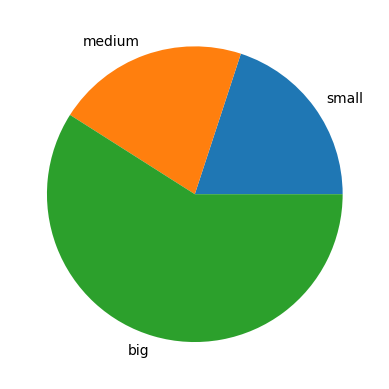

============ Agency Type ==================
Travel Agency : 336
Airlines : 591


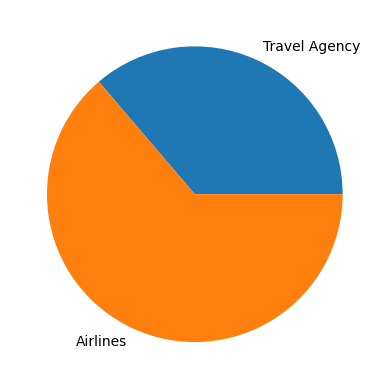

============ Product Name ==================
small : 124
medium : 153
big : 650


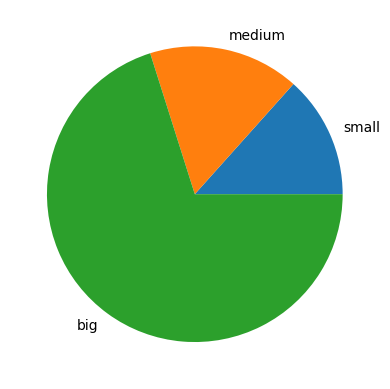

============ Destination ==================
medium : 150
big : 155
small : 60
sign : 562


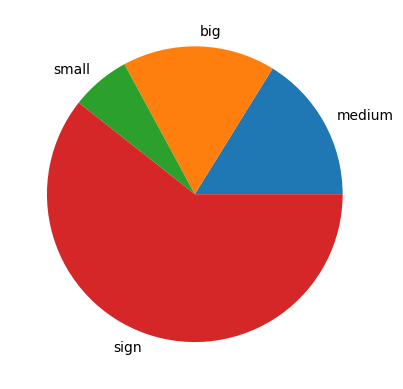

In [13]:
show_all()

Таким образом получилось сократить количество стран с 149 до 4

###### Обработка числовых признаков

Посмотрим на числовые признаки

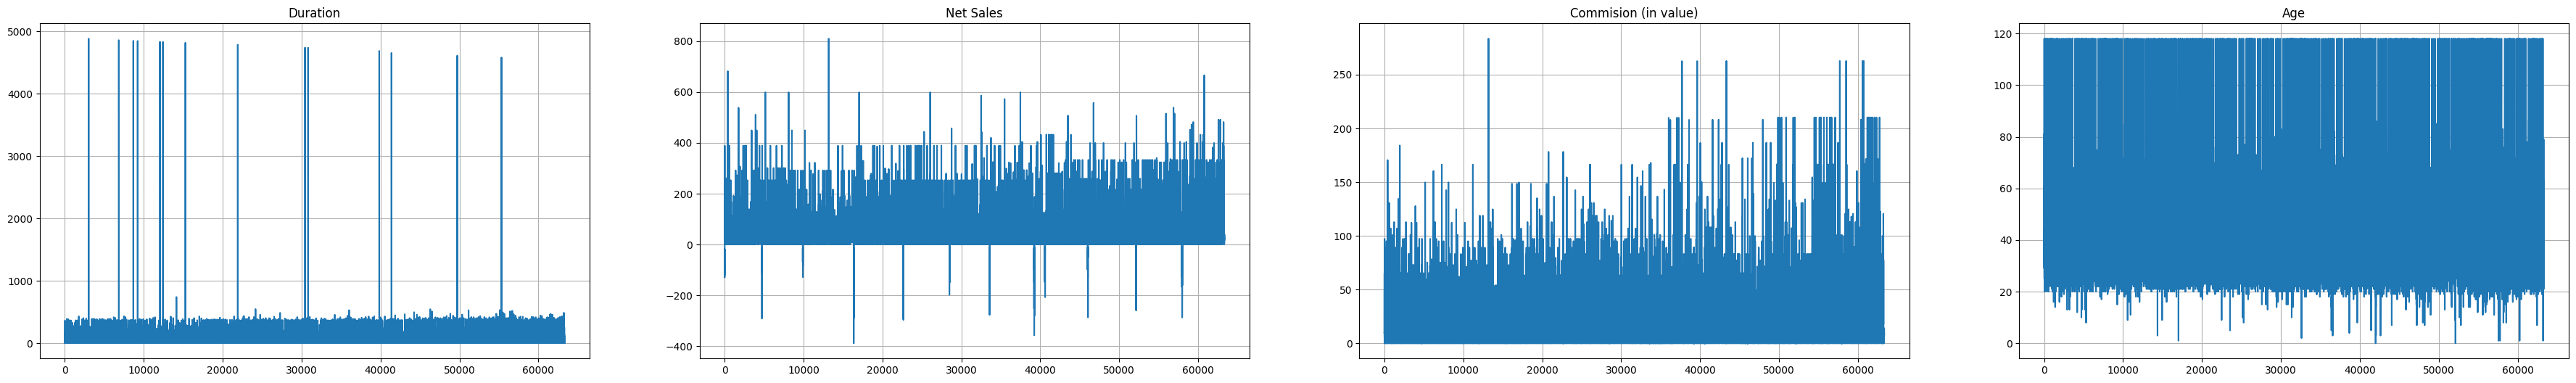

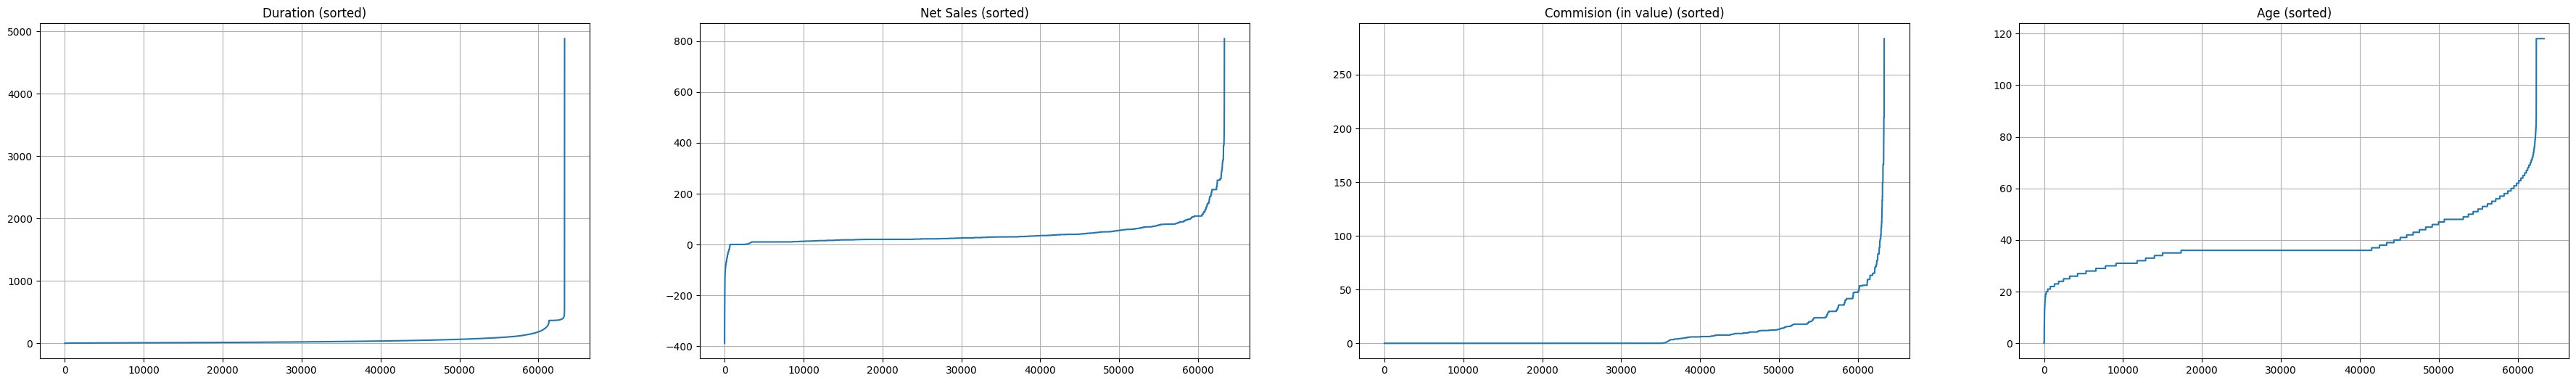

In [14]:
def show_all_count(key = None):
    q = list(df.dtypes[df.dtypes != "object"].keys())
    c = not (key is None)
    fig, ax = plt.subplots(1, len(q), figsize=(45, 6))
    for n, i in enumerate(q):
        ax[n].plot(key(df[i]) if c else df[i])
        ax[n].set_title(i + (f" ({key.__name__})" if c else ''))
        ax[n].grid(True)
    plt.show()

show_all_count()
show_all_count(sorted) # так же выведем в отсортированном порядке, что бы наглядно увидеть долю выбросов

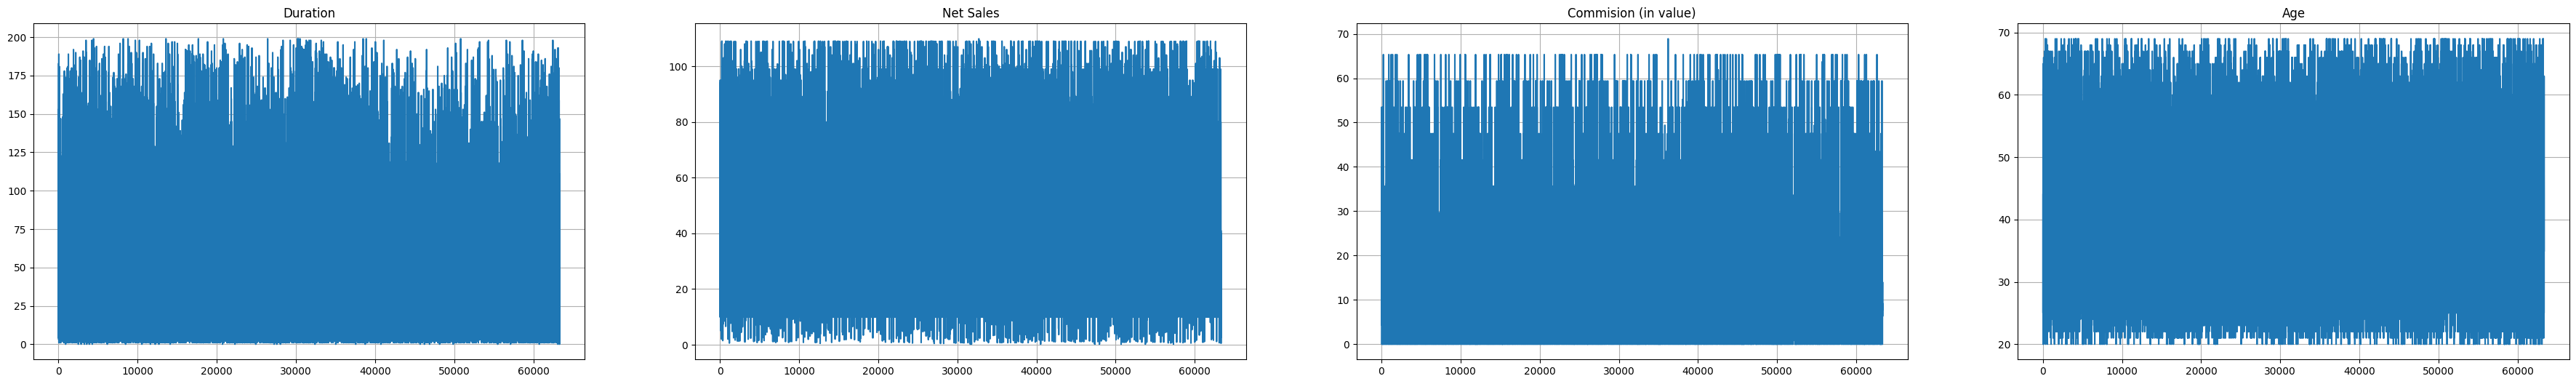

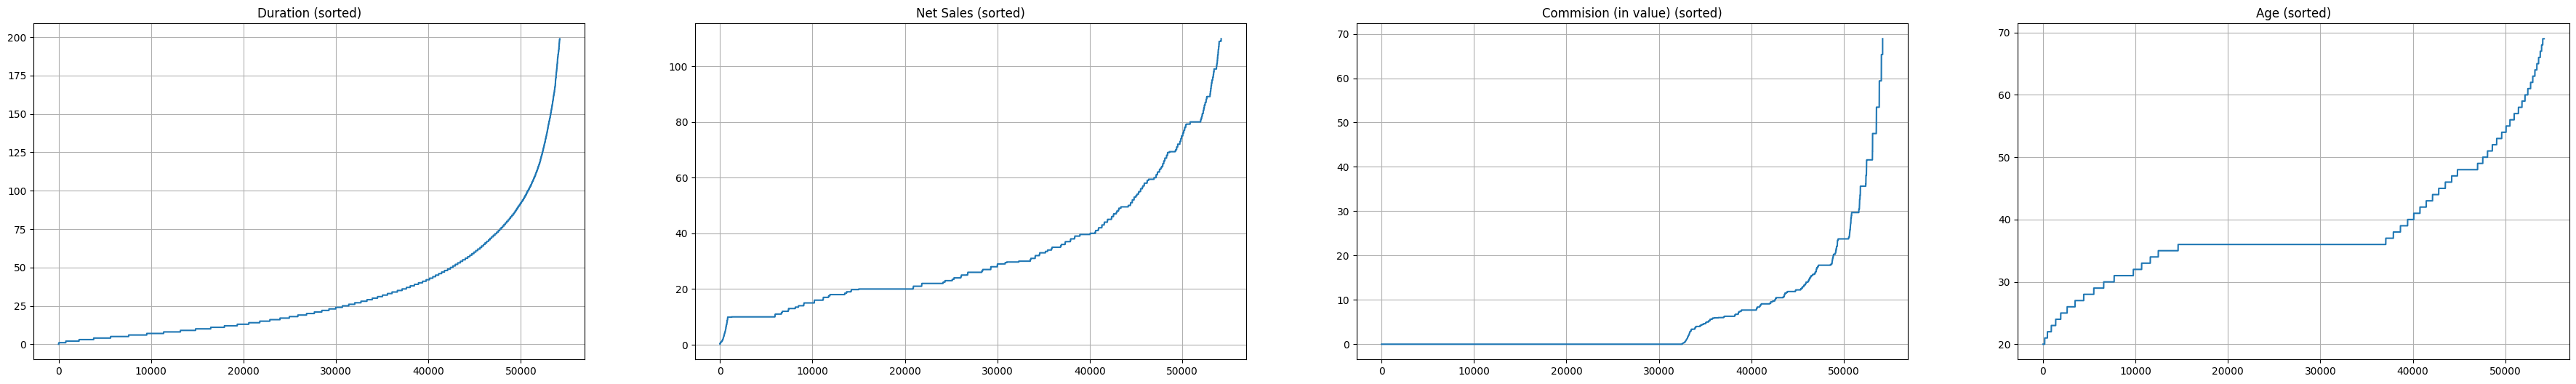

In [15]:
### убираем очевидные выбросы
df = df[df['Duration'] < 200]
df = df[(df['Net Sales'] < 110) & (df['Net Sales'] > 0)]
df = df[df['Commision (in value)'] < 80]
df = df[(df['Age'] < 70) & (df['Age'] >= 20)]

show_all_count()
show_all_count(sorted)

##### Использую Numpy

In [16]:
# теперь можно конвертировать обработаные данные в numpy массив и применить к нему 'написанные функции'

cat_features_mask = (df.dtypes == "object").loc[df.columns != 'Claim'].values
DX = df.loc[:, df.columns != 'Claim'].to_numpy()
X = []
y = np.where(df['Claim'].to_numpy() == 'Yes', 1.0, 0.0)

for n, i in enumerate(cat_features_mask):
    if i:
        X.append(onehot_encoding(DX[:, n]).transpose())
    else:
        X.append(minmax_scale(DX[:, n]))

X = np.vstack(X).transpose()
X = np.matrix(X, dtype=np.float64)
print(X)
print(y)

[[1.         0.         0.         ... 0.41911362 0.16748911 0.48979592]
 [1.         0.         0.         ... 0.1583075  0.06371553 0.10204082]
 [1.         0.         0.         ... 0.85546234 0.34107402 0.28571429]
 ...
 [0.         0.         1.         ... 0.16241109 0.09143687 0.75510204]
 [0.         0.         1.         ... 0.16241109 0.09143687 0.87755102]
 [0.         0.         1.         ... 0.23536385 0.13207547 0.30612245]]
[0. 0. 1. ... 0. 0. 0.]


### Применение линейной регрессии (10 баллов)

Это задача классификации, но её можно решить с помощью линейной регрессии, если округлять предсказанный ответ до целого и выбирать ближайший по значению ответ из множества {0, 1}.

Вынесите признак 'Claim' в вектор ответов и разделите датасет на обучающую и тестовую выборку в соотношении 80 к 20. Зафиксируйте random_state.

**Подсказка:** быстро перевести Yes/No в 1/0 можно так - np.where(df['Claim'] == 'Yes', 1,0)

In [17]:
# разделение на test/train
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=228)

Найдите аналитическое решение для обучающей выборки: обычное и регуляризацией l2. 

In [18]:
def Q(x): # функция риска
    return x @ x.T

# посчитайте аналитическое решение

class LinearRegression:
    def __init__(self, biases:bool = True) -> None:
        self.biases = biases
        self.w = None
    
    def fit(self, X_train, y_train):
        Xt = X_train
        if self.biases:
            Xt = np.hstack((np.ones((Xt.shape[0], 1)), X_train))
        
        self.w = np.linalg.inv(Xt.transpose() @ Xt) @ Xt.transpose() @ y_train
        self.w = self.w.T

    def calculate(self, x):
        if not self.w is None:
            tx = np.hstack([np.ones((x.shape[0], 1)), x]) if self.biases else x
            return np.array((tx @ self.w).T)
        

Lr = LinearRegression()
Lr.fit(X_train, y_train)
o = Lr.calculate(X_test)
print(Lr.w) # значение весов
print(o) # значение выхода
print(Q(o - y_test))

[[ 9.02358377e+11]
 [-2.69605018e+11]
 [-2.69605018e+11]
 [-2.69605018e+11]
 [-7.05910823e+11]
 [-7.05910823e+11]
 [ 7.31574648e+10]
 [ 7.31574648e+10]
 [ 7.31574648e+10]
 [-2.34934496e-02]
 [ 1.56198513e-01]
 [ 2.19427537e-01]
 [ 2.50649585e-01]
 [ 2.60211944e-01]
 [ 1.61312315e-02]
 [ 1.45008126e-02]
 [-6.80666329e-03]]
[[-0.15523987  0.07017144 -0.0019911  ...  0.00485749 -0.00104822
   0.07065339]]
[[160.71489252]]


In [19]:
# посчитать аналитическое решение с регуляризацией

class LinearRegressionWithRegularization:
    def __init__(self, biases:bool = True) -> None:
        self.biases = biases
        self.w = None
    
    def fit(self, X_train, y_train, _lambda = 1):
        Xt = X_train
        if self.biases:
            Xt = np.hstack((np.ones((Xt.shape[0], 1)), X_train))
        
        I = np.eye(X.shape[1] + 1) if self.biases else np.eye(X.shape[1])
        self.w = np.linalg.inv(Xt.transpose() @ Xt + _lambda**2 * I) @ Xt.transpose() @ y_train
        self.w = self.w.transpose()

    def calculate(self, x):
        if not self.w is None:
            tx = np.hstack([np.ones((x.shape[0], 1)), x]) if self.biases else x
            return np.array((tx @ self.w).T)

Lr = LinearRegressionWithRegularization()
Lr.fit(X_train, y_train)
o = Lr.calculate(X_test)
print(Lr.w) # значение весов
print(o) # значение выхода
print(Q(o - y_test)/len(y_test)) # MSE

[[ 0.00808335]
 [ 0.03515638]
 [-0.01515058]
 [-0.01192245]
 [ 0.0028581 ]
 [ 0.00522525]
 [ 0.00597598]
 [-0.00064248]
 [ 0.00274986]
 [ 0.00290538]
 [ 0.00273768]
 [ 0.00245895]
 [ 0.00147221]
 [ 0.00141452]
 [ 0.01613048]
 [ 0.01448584]
 [-0.00680244]]
[[0.00293754 0.05776243 0.00535524 ... 0.00179715 0.00798709 0.00285797]]
[[0.00941359]]


Постройте модель LinearRegression, примените к тестовой выборке и посчитайте MSE (можно использовать библиотеку sklearn)

In [20]:
# обучите модель линейной регрессии LinearRegression на обучающей выборке, примените к тестовой

In [21]:
# посчитайте MSE, предварительно округлив предсказанные ответы до целого

### Вывод (1 балла)

Напишите краткий вывод по заданию (достаточно пары предложений). Расскажите, какие способы предобработки данных вы выбрали и почему. Насколько хороша ваша модель?